# Lecture 22: $k$-SAEs and Sentence Transformers

This is a code-heavy lecture that we'll go through piece-by-piece.

In [ ]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

import pandas as pd
from tqdm.notebook import tqdm
from collections import namedtuple
import seaborn as sns


SAEOutput = namedtuple("SAEOutput", ["x_hat", "h_sparse", "h"])


class TopKSAE(nn.Module):
    """
    A simple k-SAE.
    """
    def __init__(
            self, 
            embed_dim: int, 
            expansion_factor: float,
            k: int
            ):
        """
        Initializes a TopKSAE with embed_dim*expansion_factor total latents
        and k active.
        """
        super().__init__()
        self.k = k
        self.h_dim = int(embed_dim*expansion_factor)
        self.encoder = nn.Linear(embed_dim, self.h_dim)
        self.decoder = nn.Linear(self.h_dim, embed_dim)

    def forward(self, x: Tensor) -> SAEOutput:
        h = self.encoder(x)
        topk, _ = torch.topk(h, self.k, dim=1)
        mask = h >= topk[:, [-1]]
        h_sparse = h * mask.float()
        x_hat = self.decoder(h_sparse)

        return SAEOutput(x_hat, h_sparse, h)


SAELossOutput = namedtuple("SAELossOutput", ["total_loss", "mse_loss", "aux_loss"])


class TopKSAELoss(nn.Module):
    """
    Implements MSE and auxiliary loss following
    O'Neill et al. 2024 (ghost grads trick).
    """
    def __init__(
            self, 
            n_latents: int, 
            k_active: int, 
            samples_per_epoch: int,
            k_aux: int = None, 
            aux_scale: float = 1/32
    ): 
        super().__init__()
        self.n_latents = n_latents
        self.k_active = k_active
        self.k_aux = k_aux if k_aux is not None else 2*k_active
        self.aux_scale = aux_scale
        self.samples_per_epoch = samples_per_epoch
    
        self.register_buffer("latent_activations", torch.zeros(n_latents))

        self.samples_processed = 0

    def update_dead_latents(self, h_sparse: Tensor):
        self.latent_activations += (h_sparse.abs().sum(dim=0) > 0).float()
        self.samples_processed += h_sparse.shape[0]

        if self.samples_processed >= self.samples_per_epoch: 
            self.dead_latents = self.latent_activations == 0
            self.latent_activations.zero_()
            self.samples_processed = 0
    
    def forward(
            self, 
            x,
            sae_output: SAEOutput,
            sae: TopKSAE
    ) -> SAELossOutput:
        x_hat, h_sparse, _ = sae_output
        
        mse_loss = F.mse_loss(x_hat, x)
        self.update_dead_latents(h_sparse)
        aux_loss = torch.tensor(0.0, device=x.device)

        if hasattr(self, "dead_latents") and self.dead_latents.any():
            e = x - x_hat
            z = torch.zeros_like(h_sparse)
            z[:, self.dead_latents] = sae.encoder(x)[:, self.dead_latents]
            k = min(self.k_aux, self.dead_latents.sum().item(), z.size(1))

            if k > 0:
                values, _ = torch.topk(z[:, self.dead_latents], k, dim=1)
                kth_values = values[:, -1].unsqueeze(1)
                mask = (z[:, self.dead_latents] >= kth_values).float()
                z[:, self.dead_latents] *= mask
            
            e_hat = sae.decoder(z)

            aux_loss = F.mse_loss(e_hat, e)

        total_loss = mse_loss + self.aux_scale*aux_loss

        return SAELossOutput(total_loss, mse_loss, aux_loss)
    
# This is our training loop
def train_sae(
        X: Tensor,
        expansion_factor: float, 
        k: int,
        num_training_steps: int = 20000,
        lr: float = 1e-4,
        batch_size: int = 2048,
        device: str = "cpu",
        log_every: int = 100
) -> tuple[TopKSAE, pd.DataFrame]:
    """
    Train a k-SAE.
    """
    samples_per_epoch, embed_dim = X.size()
    sae = TopKSAE(embed_dim, expansion_factor, k)
    sae_loss = TopKSAELoss(sae.h_dim, k, samples_per_epoch)
    optimizer = torch.optim.AdamW(sae.parameters(), lr=lr)

    total_loss_log = []
    mse_loss_log = []
    aux_loss_log = []
    steps_log = []

    sae.train()
    sae.to(device)
    sae_loss.to(device)
    for step in tqdm(range(num_training_steps)):
        start = (step * batch_size) % samples_per_epoch
        stop = start + batch_size
        if stop < samples_per_epoch:
            batch = X[start:stop].to(device)
        else:
            part1 = X[start:]
            part2 = X[:stop % samples_per_epoch]
            batch = torch.cat([part1, part2]).to(device)
        
        optimizer.zero_grad()
        sae_output = sae(batch)
        total_loss, mse_loss, aux_loss = sae_loss(batch, sae_output, sae)

        total_loss.backward()
        optimizer.step()

        if step % log_every == 0: 
            total_loss_log.append(total_loss.cpu().item())
            mse_loss_log.append(mse_loss.cpu().item())
            aux_loss_log.append(aux_loss.cpu().item())
            steps_log.append(step)
    
    sae.cpu()
    
    training_logs = pd.DataFrame(
        {
            "step": steps_log, 
            "total_loss": total_loss_log,
            "mse_loss": mse_loss_log,
            "aux_loss": aux_loss_log
        }
    )
    return sae, training_logs 

# This is how we get sparse activations from our SAE after it's trained.
def infer_sparse(X, sae, batch_size: int = 2048, device: str = "cpu") -> Tensor:
    """Perform batched inference with a trained k-SAE."""
    n = X.size(0)

    sae.eval()
    sae.to(device)

    H = []
    for i in range(0, n, batch_size):
        with torch.no_grad():
            batch = X[i:i+batch_size].to(device)
            _, h_sparse, _ = sae(batch)
        H.append(h_sparse.cpu())
    
    return torch.cat(H)


In [2]:
# ST stuff
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-l6-v2")

# News Data
data_path = "../data/news/news_text.csv.gz"

df = pd.read_csv(data_path).sample(50000)

In [3]:
df.value_counts("label")

label
Sports      12577
World       12545
Sci_Tech    12448
Business    12430
Name: count, dtype: int64

In [4]:
# Get sentence transformer embeddings of our news data as a tensor
X = st_model.encode(df.body.tolist(), convert_to_tensor=True, show_progress_bar=True)

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

In [5]:
X.shape

torch.Size([50000, 384])

In [6]:
sae, logs = train_sae(X.clone(), expansion_factor=2, k=16, device="cuda")

  0%|          | 0/20000 [00:00<?, ?it/s]

<Axes: xlabel='step', ylabel='value'>

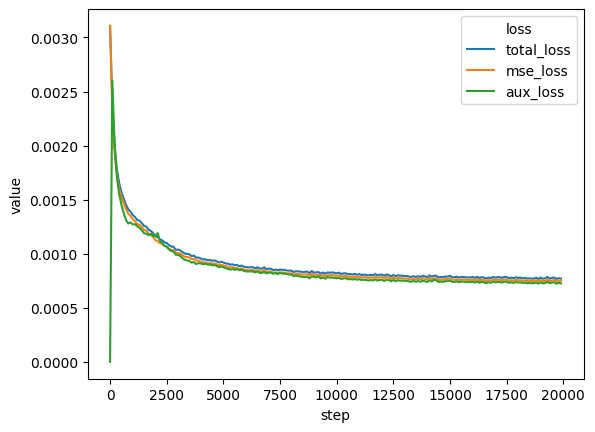

In [7]:
sns.lineplot(
    data=logs.melt(["step"], var_name="loss"),
    x="step",
    y="value", 
    hue="loss"
)

In [8]:
H = infer_sparse(X.clone(), sae, device="cuda")

In [9]:
H_idx_sorted = torch.argsort(-H, dim=0)

In [10]:
# Number of dead latents
(H.sum(dim=0) == 0).sum()

tensor(9)

## Feature Interpretation (Verbalization)

### Sampling

In [11]:
from collections import defaultdict


def get_positive_samples(
        dataframe: pd.DataFrame, 
        sorted_feature_activations: Tensor, 
        feature_activations: Tensor,
        num_samples: int = 5, 
        num_features: int = 5
        ) -> dict:
    """Get positive samples (highest activating for each feature)."""
    positive_samples = defaultdict(list)
    for i in range(num_features): 
        for j in range(num_samples):
            index = sorted_feature_activations[j, i].item()
            text = dataframe.iloc[index]["body"]
            activation = feature_activations[index, i]
            if activation > 0: 
                positive_samples[i].append({
                    "index": index, 
                    "text": text, 
                    "activation": round(activation.item(), 2)
                })
    
    return positive_samples

def get_negative_samples(
        dataframe: pd.DataFrame, 
        feature_activations: Tensor,
        num_samples: int = 5, 
        num_features: int = 5,
    ) -> dict:
    """Get negative samples (zero activation for each feature)."""
    negative_samples = defaultdict(list)
    for i in range(num_features):
        zero_act_idx = (
            torch.argwhere(feature_activations[:, i] == 0)
                .squeeze()
        )
        random_idx = torch.randint(
            zero_act_idx.size(0), 
            size=[min(num_samples, zero_act_idx.size(0))] # Should sample without replacement
        )
        sampled_zero_act_idx = zero_act_idx[random_idx]
        for idx in sampled_zero_act_idx:
            negative_samples[i].append({
                "index": idx.item(),
                "text": dataframe.iloc[idx.item()]["body"],
                "activation": 0
            })
    
    return negative_samples

def get_nonzero_samples(
        dataframe: pd.DataFrame,
        feature_activations: Tensor,
        num_samples: int = 5,
        num_features: int = 5,
    ) -> dict:
    """Get non-zero samples (non-zero activation for each feature)."""
    samples = defaultdict(list)
    for i in range(num_features):
        nz_idx = (
            torch.argwhere(feature_activations[:, i])
                .squeeze()
        )
        random_idx = torch.randint(
            nz_idx.size(0),
            size=[min(num_samples, nz_idx.size(0))] # Ditto 
        )
        sampled_nz = nz_idx[random_idx]
        for idx in sampled_nz:
            samples[i].append({
                "index": idx.item(),
                "text": dataframe.iloc[idx.item()]["body"],
                "activation": feature_activations[idx.item(), i]
            })
    return samples

In [12]:
num_features = 5

positive_samples = get_positive_samples(df, H_idx_sorted, H, num_features=num_features)
negative_samples = get_negative_samples(df, H, num_features=num_features)
nonzero_samples = get_nonzero_samples(df, H, num_features=num_features)

In [13]:
positive_samples[0]

[{'index': 29346,
  'text': 'World Cup overall leader Bode Miller won a giant slalom for the second time this season Sunday, rallying from fourth place in the opening leg.',
  'activation': 0.7},
 {'index': 49265,
  'text': 'Bode Miller won his fifth victory of the World Cup season in a giant slalom on Sunday after the three men ahead of him all faltered.',
  'activation': 0.68},
 {'index': 20964,
  'text': 'World Cup leader Bode Miller won a slalom Monday to join Marc Girardelli as the only men to win races in all four disciplines in a season.',
  'activation': 0.68},
 {'index': 39588,
  'text': 'Bode Miller made his ambitions clear when he won his fifth World Cup race of the season in a giant slalom on Sunday ahead of the best two skiers of recent years.',
  'activation': 0.67},
 {'index': 704,
  'text': 'LAKE LOUISE, Alta. (CP) - American Bode Miller won his first World Cup super-giant slalom race Sunday, giving him his third consecutive victory of the season and moving him into an 

In [14]:
negative_samples[0]

[{'index': 42974,
  'text': "Reuters - FedEx Corp.'s  express air\\shipping unit has been ordered by the U.S. government to repay\\ #36;29 million in excess funds received under an act established\\after the Sept. 11, 2001, attacks, the company said on Friday.",
  'activation': 0},
 {'index': 9795,
  'text': 'Lord James Hanson, a wealthy industrialist whose business prospered by acquiring poorly run, low-tech companies and turning them into money makers, died Monday after a long battle with cancer, his spokesman said.',
  'activation': 0},
 {'index': 18044,
  'text': 'Pilots at Delta Air Lines overwhelmingly approved a new five-year contract with \\$1 billion in annual concessions sought by the airline.',
  'activation': 0},
 {'index': 17527,
  'text': "AP - Oracle Corp.'s hostile  #36;7.7 billion bid for rival software maker PeopleSoft Inc. could drop by one-third to one-fourth, Oracle co-president Safra Catz said Monday.",
  'activation': 0},
 {'index': 32092,
  'text': 'Assailants f

### Interpretation

In [ ]:
interpreter_template = (
    "Your job is to interpret the role of a neuron in a neural network.\n"
    "You will see two types of text:\n\t1. Positive samples, which are texts that activate "
    "that neuron the most in our data.\n\t2. Negative samples, which are texts that do not activate "
    "that neuron at all.\nUsing these positive and negative examples, you will determine "
    "what characteristics are present in the positive samples, but entirely absent in the negative samples. "
    "If a characteristic or feature is only present in the positive examples, "
    "it means that this neuron fires on those specific textual characteristics.\n"
    "These characteristics can range from relatively simple (e.g. the inclusion of a word, phrase, or "
    "special character) to complex (e.g. discussion of certain subject matter or topics, or even stylistic "
    "or syntactic features). Use your reasoning capabilities to determine what is "
    "most likely given the available evidence. Use Occam's razor: do not propose "
    "a more complex explanation when a more simple one would suffice. " 
    "You should ultimately provide a highly specific description of what the neuron captues, as broad or overly general "
    "descriptions are not useful.\n\n"
    "When you have finished reasoning, you will write your response as a short description "
    "of the neuron using, 5 to 10 words maximum.\n\n"
    "Below are the positive and negative samples that you will use to describe our neuron:\n"
    "Positive samples:\n"
    "{positive}\n"
    "Negative samples\n"
    "{negative}\n"
    "Now, think through these instructions and the above examples until you have reached a "
    "conclusion, then provide a focused, clear, and concise description of what the neuron captures. Remember, "
    "your description should only include 5-10 words: it should NOT exceed 10 words in length.\n"
    "Do NOT include any other "
    "commentary, justification, analysis, or unrelated information in your response. Keep your description focused, clear, and brief."
)

pos_template = (
    "Activation: {activation}\n"
    "Text: {text}\n"
)

neg_template = (
    "Activation: 0\n"
    "Text: {text}\n\n"
)

In [27]:
from ollama import chat

def get_chat_response(prompt, format, model="qwen3:1.7b", think=True):
    return chat(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        format=format,
        think=think,
    ).message.content

In [28]:
from pydantic import BaseModel

class Interpretation(BaseModel):
    description: str

interpretations = {}
for i in tqdm(range(num_features)): 
    pos_examples = "\n".join(
        [pos_template.format(activation=sample["activation"], text=sample["text"])
         for sample in positive_samples[i]]
    )
    neg_examples = "\n".join(
        [neg_template.format(text=sample["text"])
         for sample in negative_samples[i]]
    )
    prompt = interpreter_template.format(positive=pos_examples, negative=neg_examples)

    interpretations[i] = get_chat_response(prompt, Interpretation.model_json_schema(), model="qwen3:4b")

  0%|          | 0/5 [00:00<?, ?it/s]

In [29]:
clean_interpretations = {k: Interpretation.model_validate_json(v).description 
                         for k, v in interpretations.items()}

clean_interpretations

{0: "Bode Miller's alpine World Cup race victory",
 1: 'The neuron captures the presence of a lawsuit in the text.',
 2: 'Text that contains suicide-related content',
 3: 'Internet-based Netflix-TiVo movie download deal',
 4: "Text including the word 'orders'"}

In [31]:
positive_samples[0]

[{'index': 29346,
  'text': 'World Cup overall leader Bode Miller won a giant slalom for the second time this season Sunday, rallying from fourth place in the opening leg.',
  'activation': 0.7},
 {'index': 49265,
  'text': 'Bode Miller won his fifth victory of the World Cup season in a giant slalom on Sunday after the three men ahead of him all faltered.',
  'activation': 0.68},
 {'index': 20964,
  'text': 'World Cup leader Bode Miller won a slalom Monday to join Marc Girardelli as the only men to win races in all four disciplines in a season.',
  'activation': 0.68},
 {'index': 39588,
  'text': 'Bode Miller made his ambitions clear when he won his fifth World Cup race of the season in a giant slalom on Sunday ahead of the best two skiers of recent years.',
  'activation': 0.67},
 {'index': 704,
  'text': 'LAKE LOUISE, Alta. (CP) - American Bode Miller won his first World Cup super-giant slalom race Sunday, giving him his third consecutive victory of the season and moving him into an 

### "Prediction" (Validation)
This is how we ensure that our feature interpretations that we generated earlier are actually interpretable.

In [35]:
predictor_template = (
    "You will read a FEATURE DESCRIPTION followed by a short TEXT.\n"
    "Your task is to determine to what extent the feature described by the "
    "FEATURE DESCRIPTION is present in the TEXT.\n"
    "You will generate a SCORE as a continuous value between -1 and 1, where\n"
    "\t-1: The feature is not present in the TEXT at all,\n"
    "\t0: Not sure or uncertain, and\n"
    "\t1: The feature is clearly present in the TEXT."
    "\n"
    "This FEATURE DESCRIPTION does not have to account for "
    "everything in the TEXT (it is not a summary). Often, a FEATURE DESCRIPTION will be highly "
    "detailed, and will only be relevant to a small portion of the TEXT.\n\n"
    "Below is the FEATURE DESCRIPTION and the TEXT for you to score:\n"
    "DESCRIPTION: {desc}\n"
    "TEXT: {text}\n"
    "Now, provide your score."
)

class Prediction(BaseModel):
    score: float

scores = {i: {"score": [], "label": []} for i in range(num_features)}
for i in range(num_features):
    nz = nonzero_samples[i] # Non-zero activation, not just the highest
    negative = negative_samples[i] # Zero activating examples
    all_samples = nz + negative
    print(f"Feature {i}: {clean_interpretations[i]}")
    for sample in tqdm(all_samples):
        prompt = predictor_template.format(
            desc=clean_interpretations[i],
            text=sample["text"]
        )
        response = Prediction.model_validate_json(
            get_chat_response(
                prompt, 
                Prediction.model_json_schema(), 
            )
        )
        scores[i]["score"].append(response.score)
        label = 1 if sample["activation"] else -1
        scores[i]["label"].append(label)    

Feature 0: Bode Miller's alpine World Cup race victory


  0%|          | 0/10 [00:00<?, ?it/s]

Feature 1: The neuron captures the presence of a lawsuit in the text.


  0%|          | 0/10 [00:00<?, ?it/s]

Feature 2: Text that contains suicide-related content


  0%|          | 0/10 [00:00<?, ?it/s]

Feature 3: Internet-based Netflix-TiVo movie download deal


  0%|          | 0/10 [00:00<?, ?it/s]

Feature 4: Text including the word 'orders'


  0%|          | 0/10 [00:00<?, ?it/s]

In [36]:
scores

{0: {'score': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
  'label': [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]},
 1: {'score': [-0.5, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
  'label': [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]},
 2: {'score': [-1.0, -1.0, 1.0, 0.8, 0.8, -1.0, -1.0, -1.0, -1.0, 0.0],
  'label': [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]},
 3: {'score': [0.5, 0.5, -0.5, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
  'label': [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]},
 4: {'score': [-1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0],
  'label': [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]}}

In [37]:
from scipy.stats import pearsonr

pred_pearson = {k: round(pearsonr(v["label"], v["score"]).statistic.item(), 4)
           for k, v in scores.items()}

/tmp/ipykernel_8084/4044038091.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pred_pearson = {k: round(pearsonr(v["label"], v["score"]).statistic.item(), 4)


In [38]:
pred_pearson

{0: nan, 1: 0.3333, 2: 0.545, 3: 0.5895, 4: 0.3333}